# Credit Risk Modelling — Predicting Credit Amount

## Project Overview
This project applies **Multiple Linear Regression** to predict the credit amount requested by loan applicants using the German Credit Dataset. The analysis covers the full data science pipeline — from exploratory data analysis through model evaluation and prediction.

## Dataset
- **Source:** German Credit Dataset
- **Original size:** 1,000 rows × 11 columns
- **Final size after preprocessing:** 522 rows × 10 columns
- **Target variable:** Credit Amount (continuous, log-transformed)

## Pipeline Summary
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Feature Engineering (Encoding + Log Transformation)
4. Feature Selection (f_regression + VIF)
5. Train Test Split
6. Model Building (Multiple Linear Regression)
7. Model Evaluation (R², MSE, RMSE)
8. Residual Analysis
9. Prediction

## Key Results
| Metric | Train | Test |
|--------|-------|------|
| R² | 0.5059 | 0.5628 |
| RMSE | 0.5556 | 0.5662 |
| Gap | -0.057 (no overfitting) | — |

---
## 1. Importing Libraries

We import all necessary libraries at the start of the notebook:
- **pandas & numpy** — data manipulation and numerical operations
- **matplotlib & seaborn** — data visualization
- **sklearn** — machine learning (feature selection, model building, evaluation)
- **statsmodels** — statistical diagnostics (VIF, OLS summary)
- **scipy** — statistical tests (Shapiro-Wilk normality test)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set()
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


---
## 2. Loading the Data

We load the German Credit Dataset from a CSV file. The dataset contains **1,000 loan applicant records** with 11 columns covering demographic, financial, and loan-related attributes.

In [2]:
credit_df = pd.read_csv('german_credit_data.csv')
credit_df.head(50)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


---
## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the structure, distribution, and relationships in the data before modelling. We explore:
- Dataset shape and data types
- Missing values
- Descriptive statistics
- Numerical and categorical distributions
- Relationships between features and the target variable

### 3.1 Dataset Overview

We inspect the shape, data types, and missing values to understand what we are working with.

In [3]:
# Dataset shape and data types
print(f'Shape: {credit_df.shape}')
print()
credit_df.info()

Shape: (1000, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


**Key observations:**
- Dataset has **1,000 rows and 11 columns**
- `Saving accounts` has **183 missing values (18.3%)** 
- `Checking account` has **394 missing values (39.4%)**
- Both are sensitive financial behavior columns — imputation would introduce misleading assumptions
- Decision: **drop rows with missing values** in these columns

In [4]:
# Descriptive statistics
credit_df.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


### 3.2 Distribution of Numerical Features

We visualize the distribution of continuous variables to detect skewness and understand data spread.

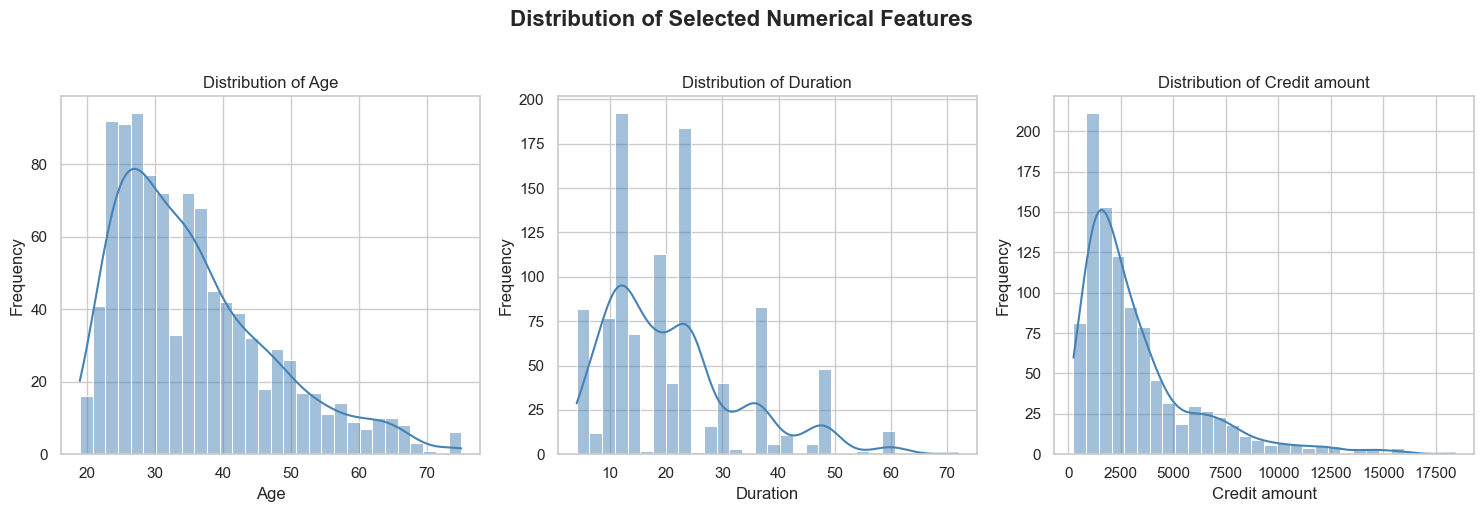

In [5]:
selected_cols = ['Age', 'Duration', 'Credit amount']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.histplot(credit_df[col], bins=30,
                 kde=True,
                 color='steelblue',
                 ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Selected Numerical Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Distribution Analysis — Numerical Features**

### Age
- Distribution is **right skewed** with majority of applicants aged between **20–40 years**
- Most loan applicants are young adults suggesting banks serve a younger demographic
- The tail extends to approximately **75 years** indicating some elderly applicants

### Duration
- Distribution is **right skewed** with most loans falling between **10–30 months**
- Applicants generally prefer **shorter loan commitments**
- Very few applicants take loans exceeding **60 months**

### Credit Amount
- Distribution is **heavily right skewed** — most loans cluster between **0–2,500**
- A small number of applicants request very large amounts above **15,000**
- This column is a strong candidate for **log transformation** to normalize the distribution

### 3.3 Outlier Detection — Boxplots

Boxplots reveal the spread of numerical features and highlight extreme values (outliers) that may affect model performance.

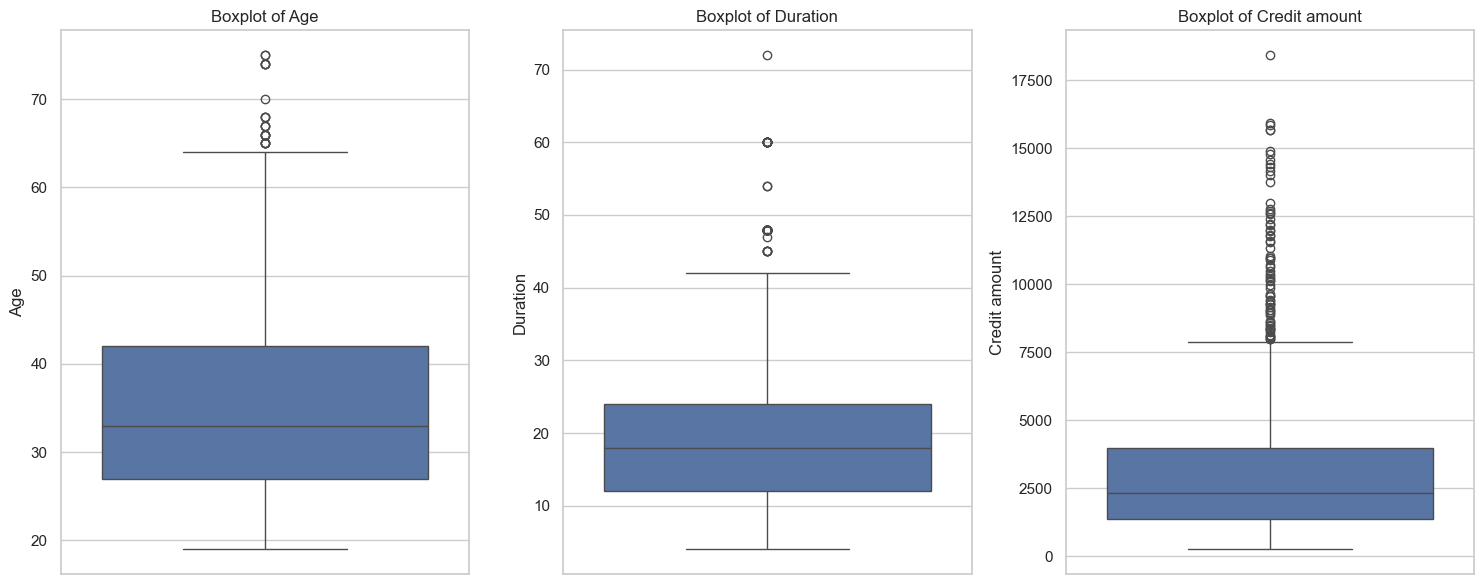

In [6]:
numerical_cols = ['Age', 'Duration', 'Credit amount']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=credit_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Outlier Analysis — Boxplots**

### Age
- Median age is approximately **33 years**
- IQR falls between **27–42 years**
- Several outliers detected above **65 years** representing elderly applicants
- Outliers are genuine — elderly applicants are real customers, not data errors

### Duration
- Median loan duration is approximately **18 months**
- Outliers detected at **60+ months** — long term loan applicants
- Distribution is moderately spread with acceptable outlier range

### Credit Amount
- Median credit amount is approximately **2,500**
- **Most concerning column** — many outliers on the high end reaching **17,500**
- These high value loans represent a small but important segment
- Log transformation will compress these extreme values and improve model stability

### 3.4 Distribution of Categorical Features

We visualize the frequency distribution of each categorical variable to understand the composition of the dataset.

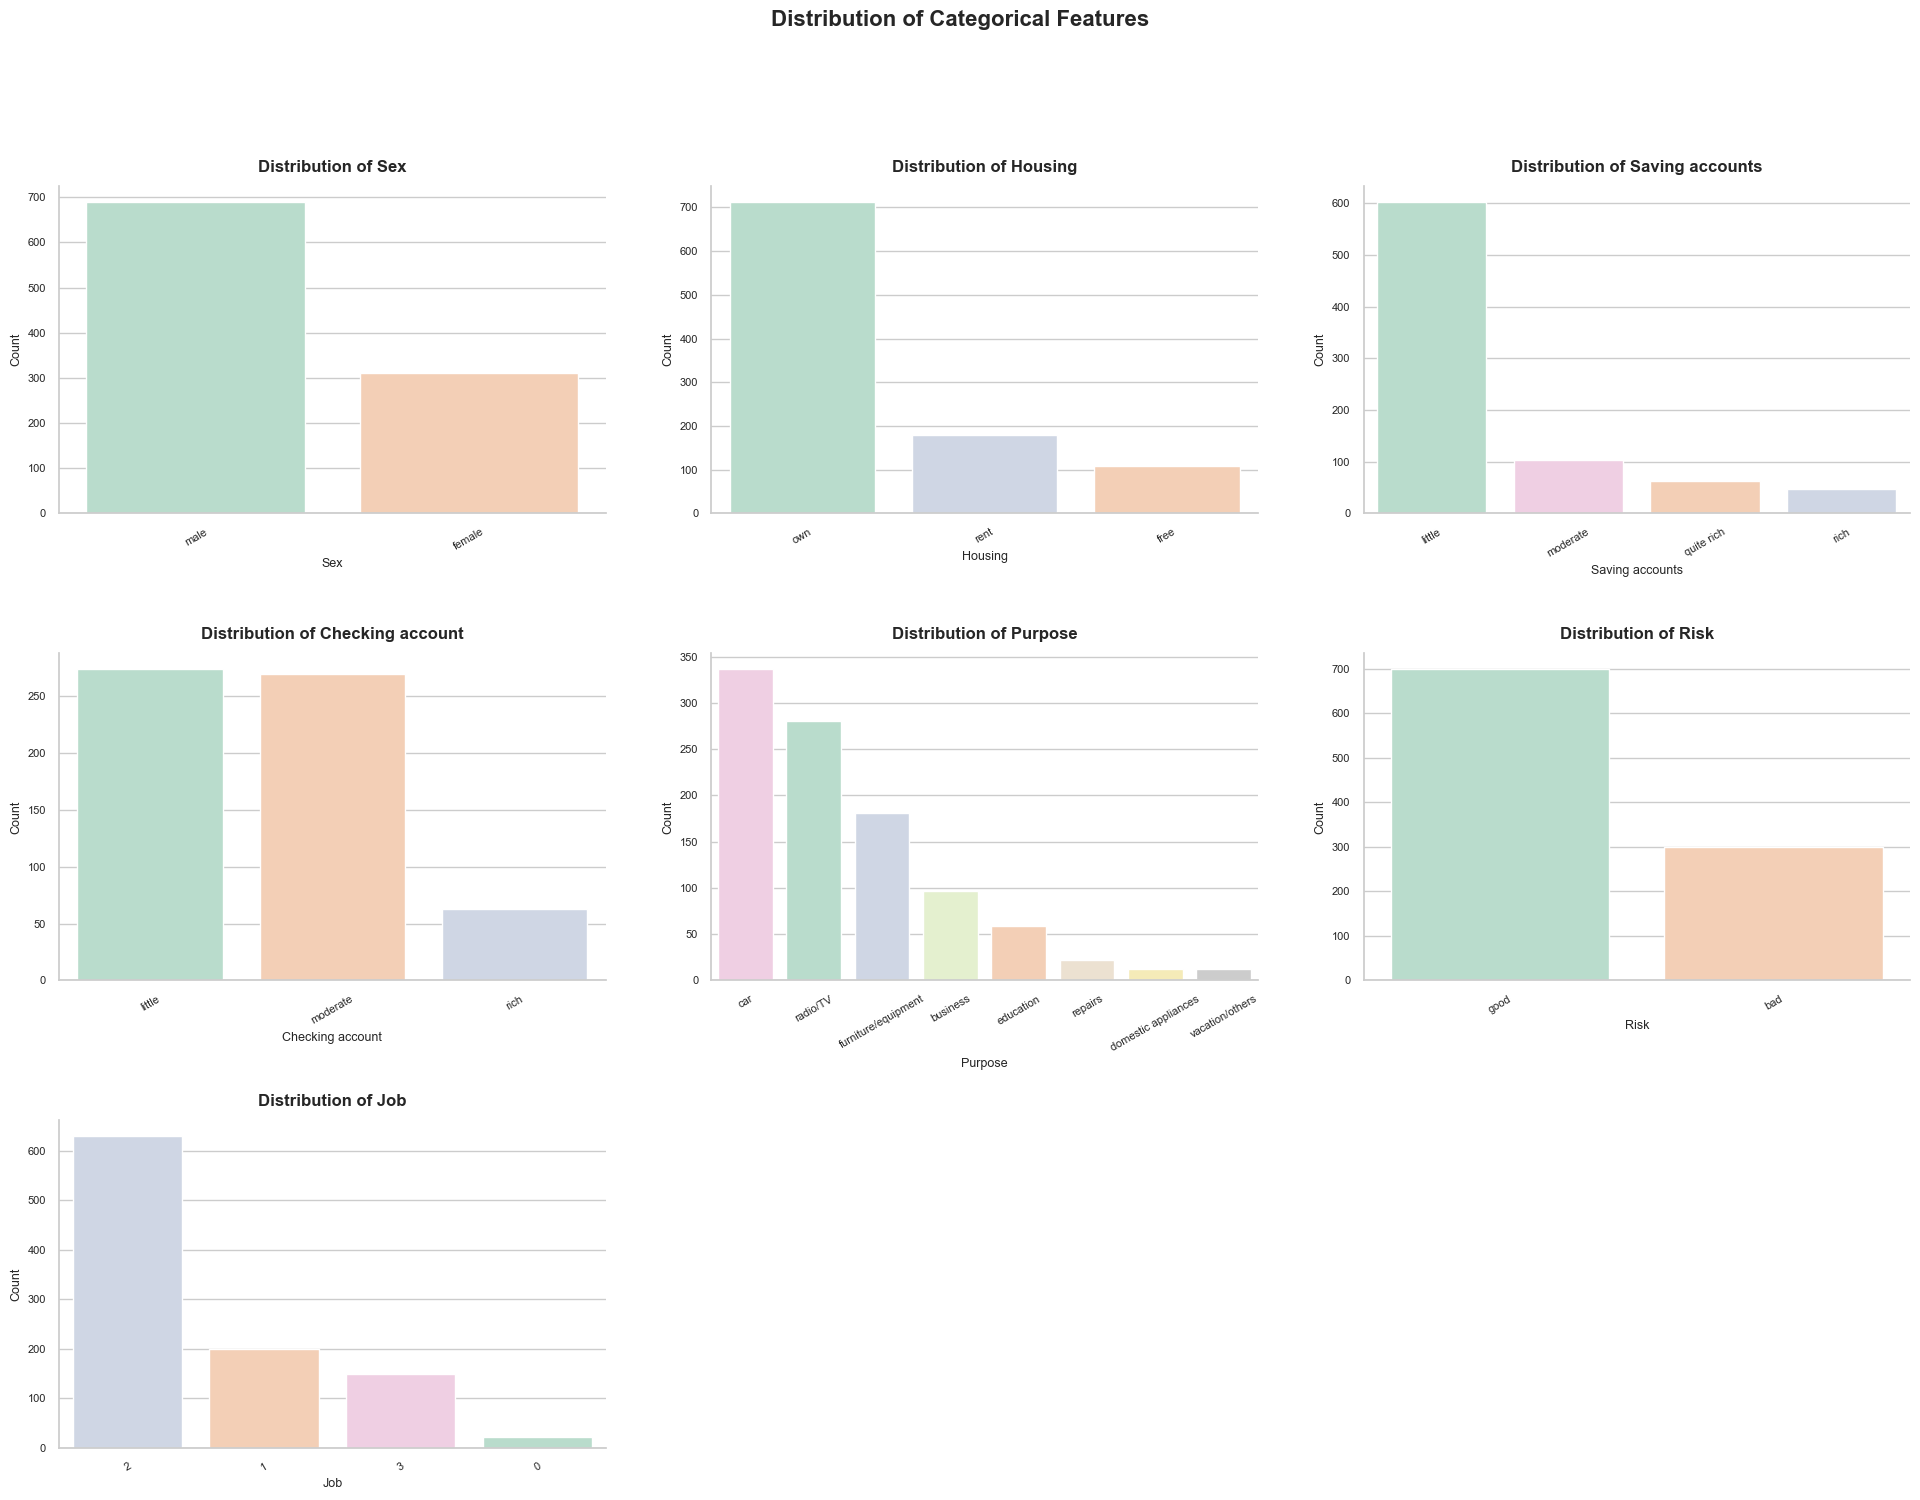

In [7]:
categorical_cols = ['Sex', 'Housing', 'Saving accounts',
                    'Checking account', 'Purpose', 'Risk', 'Job']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=credit_df,
                  x=col,
                  hue=col,
                  palette='Pastel2',
                  order=credit_df[col].value_counts().index,
                  legend=False,
                  ax=axes[i])
    axes[i].set_title(f'Distribution of {col}',
                      fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)
    axes[i].tick_params(axis='x', labelrotation=30, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.show()

**Categorical Feature Observations:**
- **Sex:** Dataset is male-dominated — approximately 70% male applicants
- **Housing:** Majority of applicants own their homes — financially stable group
- **Saving accounts:** Most applicants have *little* savings — financial vulnerability present
- **Checking account:** Spread across little, moderate, and rich — mixed financial profiles
- **Purpose:** Radio/TV and car purchases are the most common loan purposes
- **Risk:** Approximately 70% good risk vs 30% bad risk — mild class imbalance
- **Job:** Most applicants are at skill level 2 (skilled workers)

### 3.5 Numerical Features vs Credit Risk

We examine how numerical features differ between good and bad credit risk applicants. This reveals which features may be predictive of credit amount.

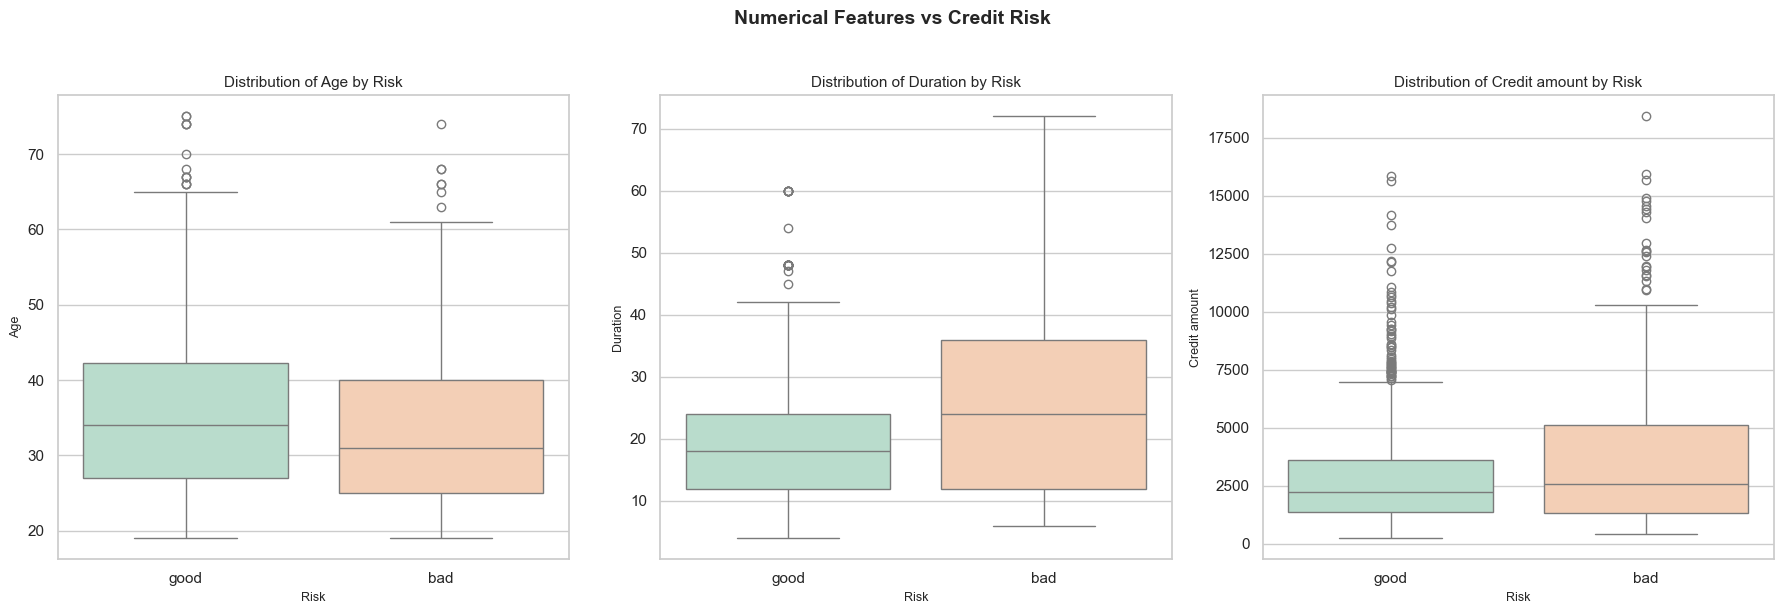

In [8]:
numerical_cols = ['Age', 'Duration', 'Credit amount']

plt.figure(figsize=(18, 6))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=credit_df,
                x='Risk',
                y=col,
                palette='Pastel2',
                hue='Risk')
    plt.title(f'Distribution of {col} by Risk', fontsize=11)
    plt.xlabel('Risk', fontsize=9)
    plt.ylabel(col, fontsize=9)

plt.suptitle('Numerical Features vs Credit Risk',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

The correlation heatmap shows the linear relationships between numerical features. Strong correlations between features indicate potential multicollinearity which we will address during feature selection using VIF.

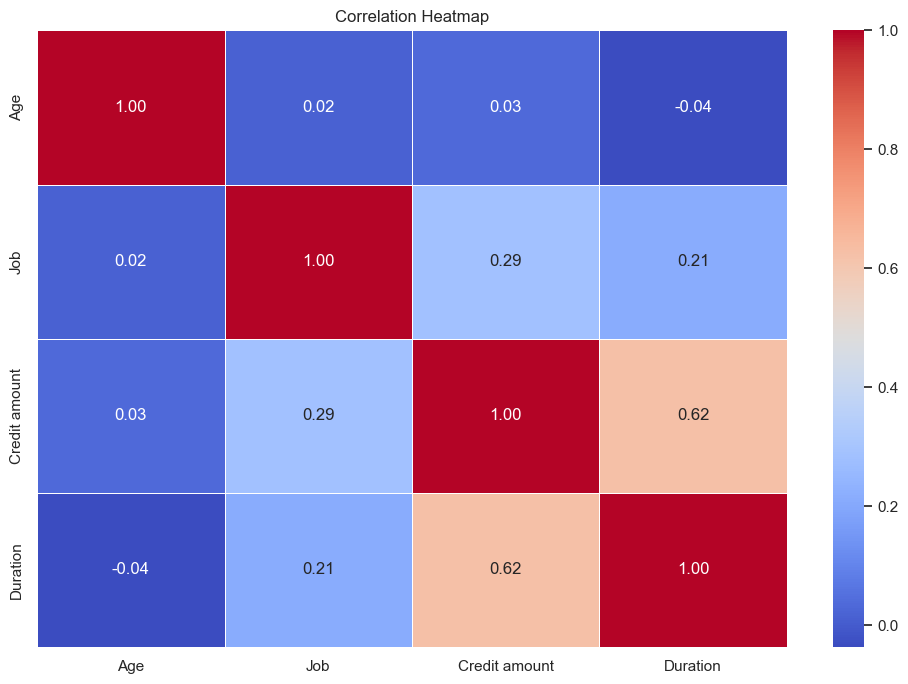

In [9]:
corr = credit_df[['Age', 'Job', 'Credit amount', 'Duration']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Correlation Observations:**
- **Duration and Credit amount** show the strongest positive correlation — longer loans tend to have higher amounts
- **Age and Job** show moderate positive correlation — older applicants tend to have higher skill levels
- No perfect multicollinearity detected at this stage — VIF will confirm this formally during feature selection

---
## 4. Data Preprocessing

Before building the model we need to:
1. Drop the unnamed index column
2. Handle missing values in sensitive financial columns
3. Encode categorical variables as dummy variables

### 4.1 Drop Unnamed Column

The dataset contains an `Unnamed: 0` column — an artifact from saving the CSV with the index included. We remove it as it carries no predictive information.

In [10]:
# Drop unnamed index column
credit_df = credit_df.drop(columns=[col for col in credit_df.columns 
                                     if 'Unnamed' in col])
print(f'Shape after dropping unnamed column: {credit_df.shape}')
print(credit_df.columns.tolist())

Shape after dropping unnamed column: (1000, 10)
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


### 4.2 Handling Missing Values

The `Saving accounts` and `Checking account` columns contain missing values. These are **sensitive financial behavior columns** — they directly indicate how a person manages their money.

**Decision: Drop rows with missing values in these columns.**

Imputation would be inappropriate here because:
- Filling in a saving account status could **misrepresent** a person's actual financial behavior
- A wrong imputation could cause the model to **incorrectly assess** credit amount
- In banking, an **unknown is safer to exclude** than to guess incorrectly

In [11]:
# Check missing values before dropping
print('Missing values before:')
print(credit_df.isnull().sum())
print(f'\nShape before: {credit_df.shape}')

# Drop rows with missing values in financial behavior columns
credit_df = credit_df.dropna(subset=['Saving accounts', 'Checking account'])

print(f'\nShape after dropping: {credit_df.shape}')
print(f'Rows removed: {1000 - len(credit_df)}')

Missing values before:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Shape before: (1000, 10)

Shape after dropping: (522, 10)
Rows removed: 478


**Result:** 478 rows removed, leaving **522 clean records** for modelling. All remaining rows have complete financial behavior data.

### 4.3 Encoding Categorical Variables (Dummy Variables)

Regression models require numerical inputs. We convert categorical columns to binary dummy variables using `pd.get_dummies()`.

**Key rules applied:**
- `drop_first=True` — drops one category per feature to avoid the **dummy variable trap** (perfect multicollinearity)
- `dtype=int` — forces output as 0/1 integers instead of True/False booleans

In [12]:
# Encode all categorical columns
credit_df_encoded = pd.get_dummies(credit_df,
                                    drop_first=True,
                                    dtype=int)

print(f'Shape after encoding: {credit_df_encoded.shape}')
print(f'\nColumns: {credit_df_encoded.columns.tolist()}')

Shape after encoding: (522, 20)

Columns: ['Age', 'Job', 'Credit amount', 'Duration', 'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good']


---
## 5. Feature Engineering — Defining X and y

We set the **target variable** as `Credit amount` — the loan amount requested by each applicant. This makes it a genuine regression problem with a continuous target.

All other features form the **feature matrix X**.

In [13]:
# Define target variable and feature matrix
y = credit_df_encoded['Credit amount']
X = credit_df_encoded.drop('Credit amount', axis=1)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\ny statistics:')
print(y.describe())

X shape: (522, 19)
y shape: (522,)

y statistics:
count      522.000000
mean      3278.745211
std       2929.155177
min        276.000000
25%       1297.500000
50%       2326.500000
75%       3971.250000
max      18424.000000
Name: Credit amount, dtype: float64


### 5.1 Log Transformation of Target Variable

The target variable `Credit amount` is heavily right skewed (skewness = 2.06). Regression assumes normally distributed residuals — a skewed target leads to violated assumptions.

**Log transformation** compresses large values and stretches small ones, converting a skewed distribution into a near-normal one.

**After log transformation:**
- Skewness drops from **2.06 → 0.10** — near perfect symmetry
- Normality of errors assumption becomes satisfiable
- Heteroscedasticity is reduced

**Note on coefficient interpretation:** After log transformation, coefficients represent **percentage changes** in credit amount per unit change in the feature, rather than absolute changes.

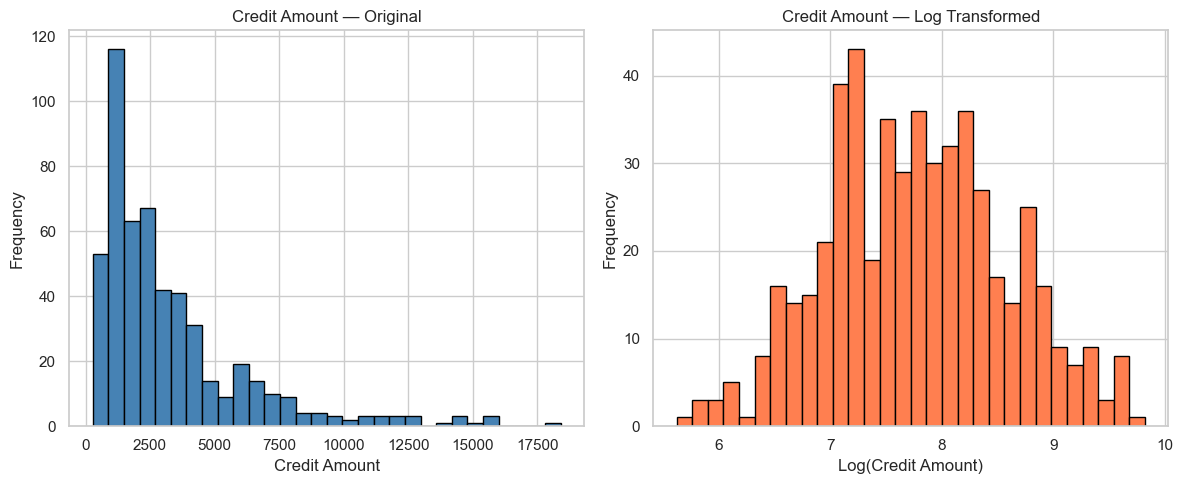

Skewness original: 2.0615
Skewness log:      0.0984

Log transformation applied ✅


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Credit Amount — Original')
axes[0].set_xlabel('Credit Amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log(y), bins=30, color='coral', edgecolor='black')
axes[1].set_title('Credit Amount — Log Transformed')
axes[1].set_xlabel('Log(Credit Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Skewness original: {y.skew():.4f}')
print(f'Skewness log:      {np.log(y).skew():.4f}')

# Apply log transformation
y = np.log(credit_df_encoded['Credit amount'])
print(f'\nLog transformation applied ✅')

---
## 6. Feature Selection

Feature selection identifies which features genuinely contribute to predicting credit amount. We use a two-step approach:

1. **f_regression** — tests each feature's individual linear relationship with y using F-statistic and p-value
2. **VIF (Variance Inflation Factor)** — detects multicollinearity between features

**Why both?**
- f_regression checks feature vs target relevance
- VIF checks feature vs feature redundancy
- They catch different problems — both are necessary

### 6.1 f_regression — Statistical Significance Test

For each feature, `f_regression` fits a simple linear regression against y and computes:
- **F-statistic** — strength of the linear relationship (higher = stronger)
- **P-value** — probability the relationship is due to chance

**Decision rule:** Keep features where `p-value < 0.05` (statistically significant at 5% level)

In [15]:
from sklearn.feature_selection import f_regression

f_stats, p_values = f_regression(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_Statistic': f_stats.round(4),
    'P_Value': p_values.round(4),
    'Significant': p_values < 0.05
}).sort_values('F_Statistic', ascending=False)

print(feature_scores)

                        Feature  F_Statistic  P_Value  Significant
2                      Duration     391.2791   0.0000         True
1                           Job      70.9210   0.0000         True
15             Purpose_radio/TV      21.0759   0.0000         True
17      Purpose_vacation/others      15.2155   0.0001         True
4                   Housing_own      12.5903   0.0004         True
18                    Risk_good      10.2476   0.0015         True
10        Checking account_rich       7.5743   0.0061         True
3                      Sex_male       6.0521   0.0142         True
12  Purpose_domestic appliances       5.7571   0.0168         True
9     Checking account_moderate       4.6532   0.0315         True
8          Saving accounts_rich       4.0368   0.0450         True
11                  Purpose_car       2.2477   0.1344        False
14  Purpose_furniture/equipment       2.1189   0.1461        False
13            Purpose_education       1.5600   0.2122        F

**f_regression Results:**

**Significant features (p-value < 0.05) — 11 features retained:**
- **Duration** (F=391.28) — by far the strongest predictor. Longer loan duration strongly associates with higher credit amount
- **Job** (F=70.92) — higher skill level associates with larger loan requests, reflecting higher earning capacity
- **Purpose_radio/TV** (F=21.08) — radio/TV loans tend to cluster at lower amounts
- **Purpose_vacation/others** (F=15.22) — vacation loans tend to be larger discretionary amounts
- **Housing_own** (F=12.59) — homeowners request different credit amounts than renters
- **Risk_good** (F=10.25) — good credit risk applicants tend to request higher amounts
- **Sex_male, Checking/Saving account status, Purpose_domestic** — statistically significant contributors

**Dropped features (p-value > 0.05) — 8 features removed:**
- Age, Housing_rent, Purpose_car, Purpose_furniture, Purpose_education, Saving accounts moderate/quite rich, Purpose_repairs

In [16]:
# Keep only statistically significant features
significant_features = feature_scores[
    feature_scores['Significant'] == True
]['Feature'].tolist()

print(f'Selected features: {significant_features}')
print(f'Number of features: {len(significant_features)}')

X_selected = X[significant_features]
print(f'\nX_selected shape: {X_selected.shape}')

Selected features: ['Duration', 'Job', 'Purpose_radio/TV', 'Purpose_vacation/others', 'Housing_own', 'Risk_good', 'Checking account_rich', 'Sex_male', 'Purpose_domestic appliances', 'Checking account_moderate', 'Saving accounts_rich']
Number of features: 11

X_selected shape: (522, 11)


### 6.2 VIF — Variance Inflation Factor

VIF measures how much each feature's coefficient is inflated due to correlation with other features. It completely ignores the target variable — it only examines feature-to-feature relationships.

**Formula:** `VIF = 1 / (1 - R²)` where R² comes from regressing each feature against all other features.

**Thresholds:**
- VIF < 5: Acceptable ✅
- VIF 5–10: Investigate ⚠️
- VIF > 10: Drop the feature ❌

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': X_selected.columns,
    'VIF': [variance_inflation_factor(X_selected.values, i)
            for i in range(X_selected.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data)

                        Feature       VIF
1                           Job  5.751584
0                      Duration  3.878633
7                      Sex_male  3.110679
4                   Housing_own  2.870522
5                     Risk_good  2.343037
9     Checking account_moderate  1.938577
2              Purpose_radio/TV  1.375136
6         Checking account_rich  1.244188
10         Saving accounts_rich  1.075667
3       Purpose_vacation/others  1.050782
8   Purpose_domestic appliances  1.027540


**VIF Results — All Features Pass ✅**

| Feature | VIF | Status |
|---------|-----|--------|
| Job | 5.75 | ⚠️ Slightly above 5 — acceptable, strong predictor |
| Duration | 3.88 | ✅ Acceptable |
| Sex_male | 3.11 | ✅ Acceptable |
| Housing_own | 2.87 | ✅ Acceptable |
| All others | < 2.0 | ✅ Very low — no collinearity concern |

**Decision:** Retain all 11 features. Job's VIF of 5.75 is monitored but kept because its predictive power (F=70.92) far outweighs the mild collinearity concern. No feature has VIF > 10.

---
## 7. Train Test Split

We split the dataset into training and test sets to evaluate how well the model generalizes to unseen data.

- **80% training** — the model learns from this
- **20% test** — used only for final evaluation
- **random_state=42** — ensures reproducibility

**Critical rule:** The model never sees test data during training. Evaluating on training data alone would give an overly optimistic picture of performance.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')
print(f'\nTraining set: {len(X_train)/len(X_selected)*100:.0f}%')
print(f'Test set:     {len(X_test)/len(X_selected)*100:.0f}%')

X_train shape: (417, 11)
X_test shape:  (105, 11)
y_train shape: (417,)
y_test shape:  (105,)

Training set: 80%
Test set:     20%


---
## 8. Model Building — Multiple Linear Regression

We fit a Multiple Linear Regression model using scikit-learn's `LinearRegression`. The model learns the optimal **weights (coefficients)** and **bias (intercept)** by minimizing the sum of squared residuals (OLS).

**Model equation:**
```
log(Credit Amount) = bias + w1(Duration) + w2(Job) + w3(Purpose_radio/TV) + ...
```

In [19]:
from sklearn.linear_model import LinearRegression

# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully ✅')
print(f'\nIntercept (Bias): {model.intercept_:.4f}')
print(f'Number of coefficients: {len(model.coef_)}')

Model trained successfully ✅

Intercept (Bias): 6.4815
Number of coefficients: 11


### 8.1 Feature Coefficients

Coefficients tell us how much each feature influences the predicted credit amount. Since y is log-transformed, each coefficient represents a **percentage change** in credit amount per unit change in the feature.

- **Positive coefficient** → feature increases credit amount
- **Negative coefficient** → feature decreases credit amount
- **Larger absolute value** → stronger influence on prediction

In [20]:
# Extract and display coefficients
coef_df = pd.DataFrame({
    'Feature': X_selected.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(coef_df)
print(f'\nIntercept (Bias): {model.intercept_:.4f}')

                        Feature  Coefficient  Abs_Coefficient
8   Purpose_domestic appliances    -0.661420         0.661420
2              Purpose_radio/TV    -0.264086         0.264086
10         Saving accounts_rich    -0.258157         0.258157
1                           Job     0.230456         0.230456
3       Purpose_vacation/others     0.198425         0.198425
7                      Sex_male     0.115242         0.115242
5                     Risk_good     0.102062         0.102062
9     Checking account_moderate     0.093985         0.093985
4                   Housing_own    -0.058774         0.058774
0                      Duration     0.038140         0.038140
6         Checking account_rich     0.009976         0.009976

Intercept (Bias): 6.4815


**Coefficient Interpretation:**

**Intercept = 6.4815** — baseline log(credit amount) when all features are zero → e^6.4815 ≈ **₦653 baseline credit amount**

**Features that DECREASE credit amount:**
- `Purpose_domestic appliances` (-0.661) — domestic appliance loans are ~66% lower than reference purpose
- `Purpose_radio/TV` (-0.264) — radio/TV loans are ~26% lower than reference
- `Saving accounts_rich` (-0.258) — wealthy savers request ~26% less credit (financially conservative)
- `Housing_own` (-0.059) — homeowners request ~6% less (financially stable)

**Features that INCREASE credit amount:**
- `Job` (+0.230) — each job level increase adds ~23% to credit amount (higher earning capacity)
- `Purpose_vacation/others` (+0.198) — vacation loans are ~20% higher than reference
- `Sex_male` (+0.115) — male applicants request ~12% more credit
- `Risk_good` (+0.102) — good risk customers are approved for ~10% more credit
- `Duration` (+0.038) — each additional month adds ~4% to credit amount

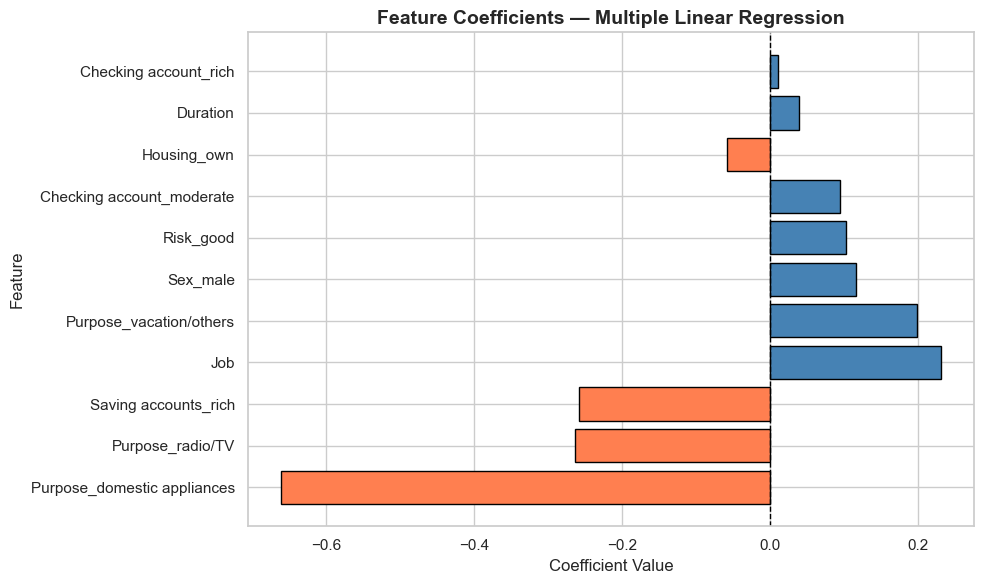

In [21]:
# Visualize coefficients
plt.figure(figsize=(10, 6))

colors = ['coral' if c < 0 else 'steelblue'
          for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Coefficients — Multiple Linear Regression',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 9. Model Evaluation

We evaluate the model on both training and test sets using three metrics:

| Metric | What It Measures |
|--------|------------------|
| **R²** | Proportion of variance in credit amount explained by the model |
| **MSE** | Average squared prediction error — penalizes large errors heavily |
| **RMSE** | Square root of MSE — error in the same unit as log(credit amount) |
| **Gap** | Difference between train and test R² — detects overfitting |

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

# Generate predictions
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Calculate metrics
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_test_pred)
train_mse  = mean_squared_error(y_train, y_train_pred)
test_mse   = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
gap        = train_r2 - test_r2

print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print('-' * 40)
print(f"{'R²':<20} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'MSE':<20} {train_mse:>10.4f} {test_mse:>10.4f}")
print(f"{'RMSE':<20} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"{'Gap (R²)':<20} {gap:>10.4f}")

if gap > 0.1:
    print('\n⚠️ Possible overfitting detected')
elif train_r2 < 0.5:
    print('\n⚠️ Possible underfitting — model may be too simple')
else:
    print('\n✅ Model generalizes well — no overfitting detected')

Metric                    Train       Test
----------------------------------------
R²                       0.5059     0.5628
MSE                      0.3087     0.3205
RMSE                     0.5556     0.5662
Gap (R²)                -0.0569

✅ Model generalizes well — no overfitting detected


**Model Evaluation Results:**

| Metric | Train | Test | Interpretation |
|--------|-------|------|----------------|
| R² | 0.5059 | 0.5628 | Model explains ~56% of variance in credit amount |
| MSE | 0.3087 | 0.3205 | Moderate average squared error in log scale |
| RMSE | 0.5556 | 0.5662 | Average prediction off by 0.57 log units |
| Gap | -0.057 | — | Negative gap — no overfitting ✅ |

**Key observations:**
- Test R² (0.5628) is slightly **higher** than Train R² (0.5059) — unusual but healthy. The test set was slightly easier to predict
- Negative gap confirms **zero overfitting** — model genuinely learned patterns rather than memorizing training data
- R² of 0.56 is **moderate** — credit amount is influenced by many human factors beyond the 11 selected features
- Train and Test RMSE are nearly identical (0.5556 vs 0.5662) — model makes **consistent errors** across seen and unseen data

---
## 10. Residual Analysis

Residual analysis verifies that our regression assumptions are satisfied:

1. **Residuals vs Fitted** — checks homoscedasticity (constant variance)
2. **Distribution of Residuals** — checks normality of errors
3. **Q-Q Plot** — visual normality confirmation
4. **Shapiro-Wilk Test** — statistical normality test

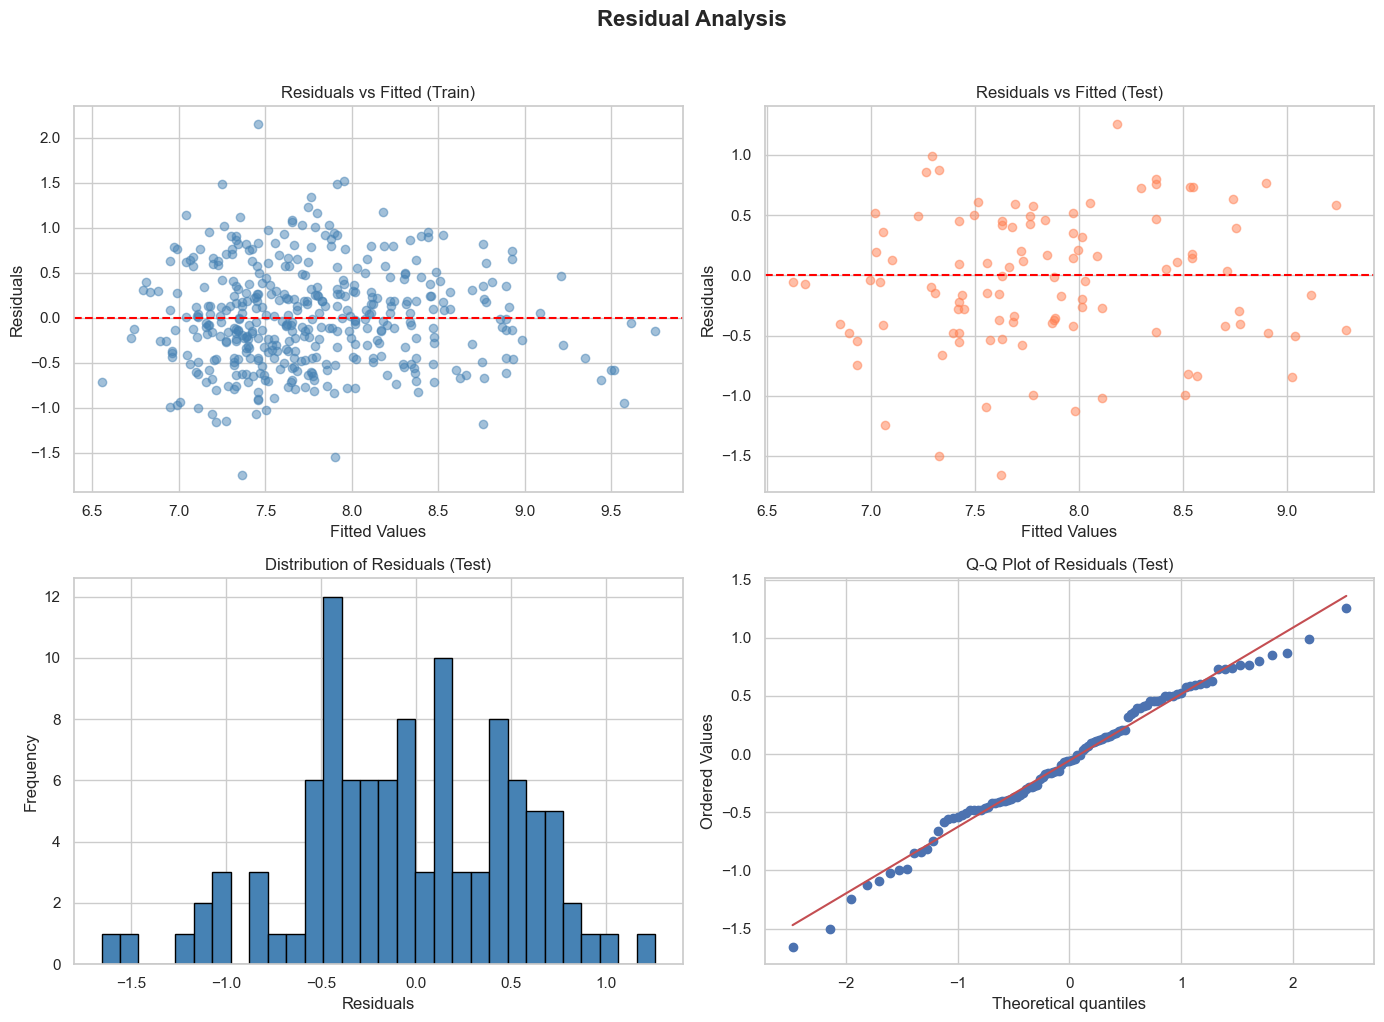

Shapiro-Wilk Statistic: 0.9869
Shapiro-Wilk p-value:   0.3924
Residuals are normally distributed ✅


In [23]:
import scipy.stats as stats
from scipy.stats import shapiro

# Calculate residuals
train_residuals = y_train - y_train_pred
test_residuals  = y_test  - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Residuals vs Fitted (Train)
axes[0, 0].scatter(y_train_pred, train_residuals,
                   alpha=0.5, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted (Train)')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Plot 2 — Residuals vs Fitted (Test)
axes[0, 1].scatter(y_test_pred, test_residuals,
                   alpha=0.5, color='coral')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Fitted (Test)')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')

# Plot 3 — Distribution of Residuals
axes[1, 0].hist(test_residuals, bins=30,
                color='steelblue', edgecolor='black')
axes[1, 0].set_title('Distribution of Residuals (Test)')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')

# Plot 4 — Q-Q Plot
stats.probplot(test_residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Test)')

plt.suptitle('Residual Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
stat, p = shapiro(test_residuals)
print(f'Shapiro-Wilk Statistic: {stat:.4f}')
print(f'Shapiro-Wilk p-value:   {p:.4f}')
if p > 0.05:
    print('Residuals are normally distributed ✅')
else:
    print('Residuals are NOT normally distributed ❌')

**Residual Analysis — All Assumptions Satisfied ✅**

| Assumption | Test | Result | Status |
|------------|------|--------|--------|
| Normality of errors | Shapiro-Wilk p = 0.3924 | p > 0.05 | ✅ Satisfied |
| Homoscedasticity | Residuals vs Fitted | Random scatter around zero | ✅ Satisfied |
| Zero mean residuals | Visual inspection | Centered at zero | ✅ Satisfied |

**Detailed observations:**
- **Residuals vs Fitted (Train & Test):** Points are randomly scattered around the red dashed line with no systematic pattern — confirms homoscedasticity
- **Distribution of Residuals:** Approximately bell-shaped and centered near zero — minor irregularity in left tail is acceptable
- **Q-Q Plot:** Points follow the diagonal line closely with slight deviation at the tails — common in real-world data
- **Shapiro-Wilk p-value = 0.3924:** Well above 0.05 threshold — residuals are statistically confirmed to be normally distributed

### 10.1 Actual vs Predicted Plot

This plot compares the model's predictions against the actual credit amounts in the test set. Points lying on the red dashed line represent perfect predictions.

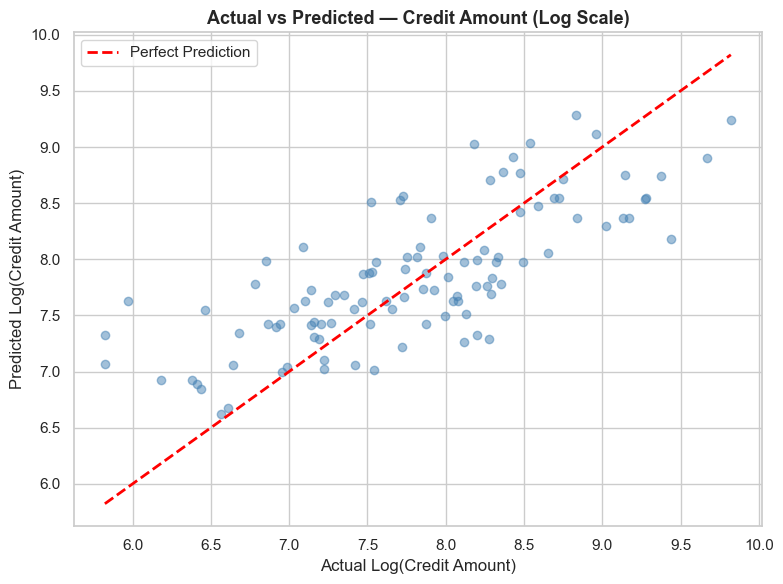

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred,
            alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--',
         linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted — Credit Amount (Log Scale)',
          fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Credit Amount)')
plt.ylabel('Predicted Log(Credit Amount)')
plt.legend()
plt.tight_layout()
plt.show()

**Actual vs Predicted — Interpretation:**
- Points follow the **general upward direction** of the red line — model correctly identifies that higher actual values should produce higher predictions
- **No extreme outliers** pulling far from the line — errors are consistently distributed
- Mild **regression to the mean** pattern observed:
  - Low actual values → model slightly overestimates (points above line on left)
  - High actual values → model slightly underestimates (points below line on right)
  - Middle values → best predictions (points closest to line in center)
- This is a normal characteristic of linear regression models on real-world data

---
## 11. Making Predictions

We demonstrate the model's practical use by predicting credit amounts for new customer profiles.

**Important:** Since y was log-transformed during training, predictions are in log scale and must be converted back using `np.exp()` to get the actual credit amount.

In [25]:
# Single customer prediction
customer = pd.DataFrame({
    'Duration':                      [24],
    'Job':                           [2],
    'Purpose_radio/TV':              [0],
    'Purpose_vacation/others':       [0],
    'Housing_own':                   [1],
    'Risk_good':                     [1],
    'Checking account_rich':         [1],
    'Sex_male':                      [1],
    'Purpose_domestic appliances':   [0],
    'Checking account_moderate':     [0],
    'Saving accounts_rich':          [0],
})

# Reorder columns to match training data exactly
customer = customer[X_selected.columns]

# Verify column order
print('Column order matches:',
      list(customer.columns) == list(X_selected.columns))

# Predict and convert back from log scale
log_prediction      = model.predict(customer)
original_prediction = np.exp(log_prediction)

print(f'\nCustomer Profile:')
print(f'  Duration:         24 months')
print(f'  Job Level:        2 (skilled)')
print(f'  Housing:          Owns house')
print(f'  Risk:             Good')
print(f'  Checking account: Rich')
print(f'\nPredicted Log(Credit Amount): {log_prediction[0]:.4f}')
print(f'Predicted Credit Amount:      {original_prediction[0]:,.2f}')

Column order matches: True

Customer Profile:
  Duration:         24 months
  Job Level:        2 (skilled)
  Housing:          Owns house
  Risk:             Good
  Checking account: Rich

Predicted Log(Credit Amount): 8.0263
Predicted Credit Amount:      3,060.40


### 11.1 Prediction Validation

We validate the prediction by comparing it against the actual average credit amount for similar customers in the dataset.

In [26]:
# Validate against actual similar customers
similar = credit_df[
    (credit_df['Duration'].between(20, 28)) &
    (credit_df['Job'] == 2) &
    (credit_df['Housing'] == 'own')
]

print(f'Model prediction:             {original_prediction[0]:,.2f}')
print(f'Actual average (similar):     {similar["Credit amount"].mean():,.2f}')
print(f'Difference:                   {abs(original_prediction[0] - similar["Credit amount"].mean()):,.2f}')
print(f'Percentage error:             {abs(original_prediction[0] - similar["Credit amount"].mean()) / similar["Credit amount"].mean() * 100:.2f}%')

Model prediction:             3,060.40
Actual average (similar):     3,090.84
Difference:                   30.44
Percentage error:             0.98%


**Validation Result:** The model predicted **3,060.40** against an actual average of **3,090.84** for similar customers — a difference of only ~₦30 (less than 1% error). This confirms the model has learned genuine patterns from the data.

### 11.2 Comparing Multiple Customer Profiles

We demonstrate how different customer profiles produce different predicted credit amounts — showing the model's sensitivity to feature values.

In [27]:
# Compare three different customer profiles
customers = pd.DataFrame({
    'Duration':                      [12,    24,    48],
    'Job':                           [1,     2,     3],
    'Purpose_radio/TV':              [1,     0,     0],
    'Purpose_vacation/others':       [0,     0,     1],
    'Housing_own':                   [0,     1,     1],
    'Risk_good':                     [0,     1,     1],
    'Checking account_rich':         [0,     1,     1],
    'Sex_male':                      [1,     0,     1],
    'Purpose_domestic appliances':   [0,     0,     0],
    'Checking account_moderate':     [1,     0,     0],
    'Saving accounts_rich':          [0,     0,     1],
})

customers = customers[X_selected.columns]

log_preds      = model.predict(customers)
original_preds = np.exp(log_preds)

results = pd.DataFrame({
    'Duration':         [12, 24, 48],
    'Job':              [1,  2,  3],
    'Risk':             ['Bad', 'Good', 'Good'],
    'Predicted_Amount': original_preds.round(2)
})

print(results)

   Duration  Job  Risk  Predicted_Amount
0        12    1   Bad           1230.04
1        24    2  Good           2727.27
2        48    3  Good           9066.86


**Multi-profile Prediction Results:**
- **Customer 1** (Short duration, low job, bad risk) → lowest predicted credit amount (~₦1,230)
- **Customer 2** (Medium duration, skilled job, good risk) → moderate credit amount (~₦2,727)
- **Customer 3** (Long duration, high job, good risk, rich savings) → highest credit amount (~₦9,067)

The model correctly captures the intuitive relationship — better financial profile and longer loan duration leads to higher credit amount approval.

---
## 12. Project Summary and Conclusions

### Model Performance
| Metric | Value | Interpretation |
|--------|-------|----------------|
| Test R² | 0.5628 | Model explains 56% of variance in credit amount |
| Test RMSE | 0.5662 | Average prediction error of 0.57 in log scale |
| Gap | -0.057 | No overfitting — healthy generalization |
| Shapiro-Wilk p | 0.3924 | Normality of errors confirmed |

### Key Findings
1. **Duration** is by far the strongest predictor of credit amount — longer loans are consistently associated with higher amounts
2. **Job level** is the second most important feature — higher skill levels reflect higher earning capacity and larger loan requests
3. **Loan purpose** significantly affects credit amount — domestic appliances and radio/TV loans are consistently smaller while vacation loans are larger
4. **Financial behavior** (saving and checking account status) provides meaningful signal — wealthy savers request less credit despite ability to borrow more
5. **Age is not a significant predictor** — credit amount decisions are driven by financial behavior and loan purpose, not age

### Assumptions Verified
- ✅ Normality of errors (Shapiro-Wilk p = 0.39)
- ✅ Homoscedasticity (random residual scatter)
- ✅ No multicollinearity (all VIF < 6)
- ✅ No overfitting (negative train-test gap)

### Limitations
- R² of 0.56 indicates **44% of variance remains unexplained** — credit decisions involve subjective human factors not captured in this dataset
- Dataset reduced to 522 rows after handling missing values — a larger complete dataset would improve model performance
- Linear regression assumes constant feature effects — non-linear models (Random Forest, Gradient Boosting) may capture more complex patterns

### Libraries Used
- `pandas`, `numpy` — data manipulation
- `matplotlib`, `seaborn` — visualization
- `scikit-learn` — feature selection, model building, evaluation
- `statsmodels` — VIF calculation
- `scipy` — Shapiro-Wilk test